In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("hotel_bookings_cleaned.csv")

In [2]:
import os

os.makedirs("Visualizations", exist_ok=True)

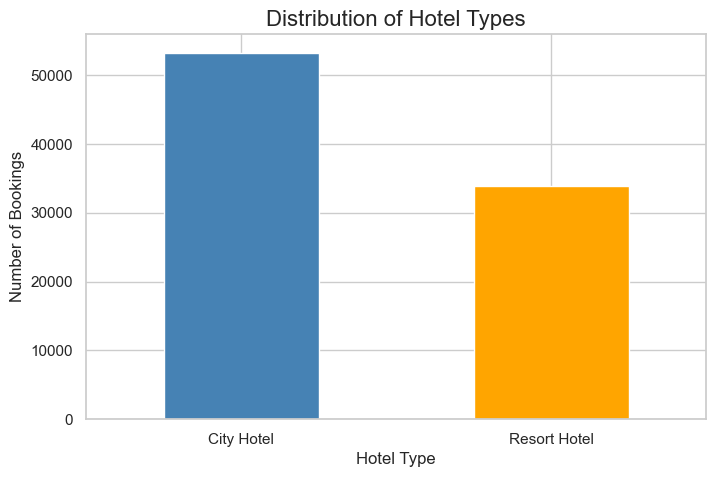

In [3]:
hotel = df["hotel"].value_counts()

plt.figure(figsize=(8,5))

hotel.plot(
    kind="bar",
    color=["steelblue","orange"]
)

plt.title("Distribution of Hotel Types", fontsize=16)

plt.xlabel("Hotel Type")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=0)

plt.savefig(
    "Visualizations/Figure1_Hotel_Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

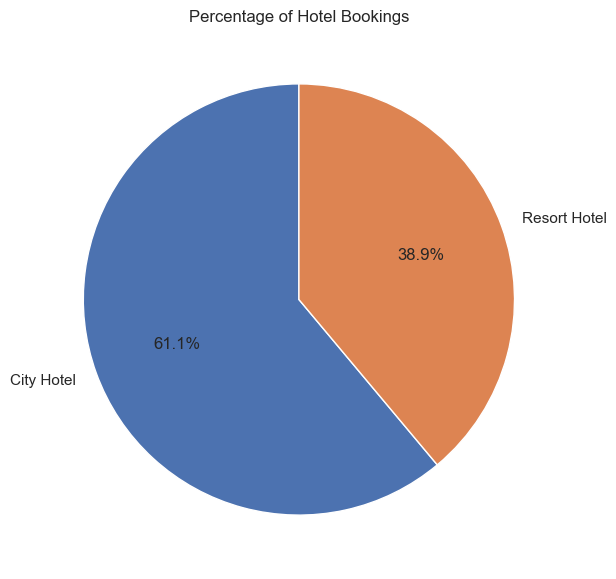

In [4]:
plt.figure(figsize=(7,7))

hotel.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Percentage of Hotel Bookings")

plt.savefig(
    "Visualizations/Figure2_Hotel_Pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

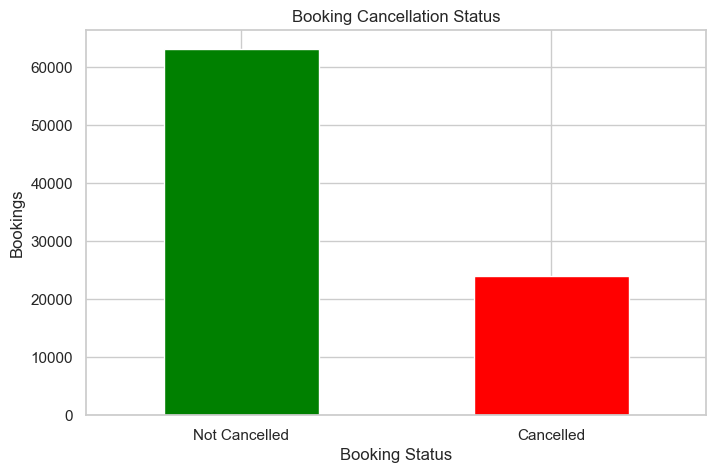

In [5]:
cancel = df["booking_status"].value_counts()

plt.figure(figsize=(8,5))

cancel.plot(
    kind="bar",
    color=["green","red"]
)

plt.title("Booking Cancellation Status")

plt.xlabel("Booking Status")

plt.ylabel("Bookings")

plt.xticks(rotation=0)

plt.savefig(
    "Visualizations/Figure3_Cancellation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

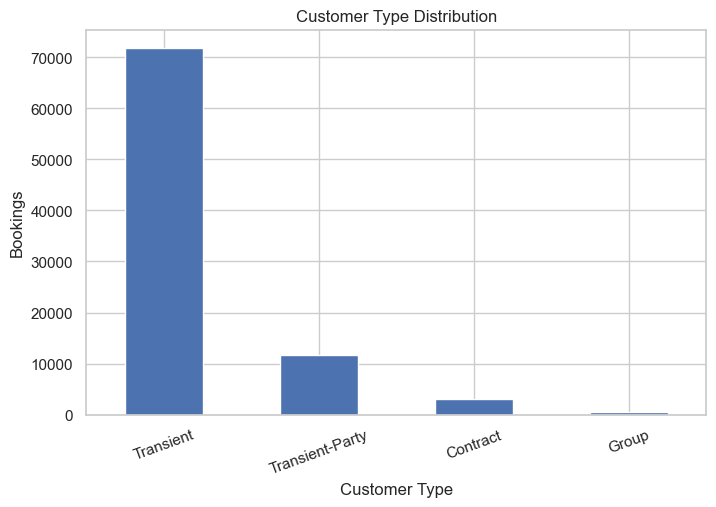

In [6]:
customer = df["customer_type"].value_counts()

plt.figure(figsize=(8,5))

customer.plot(kind="bar")

plt.title("Customer Type Distribution")

plt.xlabel("Customer Type")

plt.ylabel("Bookings")

plt.xticks(rotation=20)

plt.savefig(
    "Visualizations/Figure4_CustomerType.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

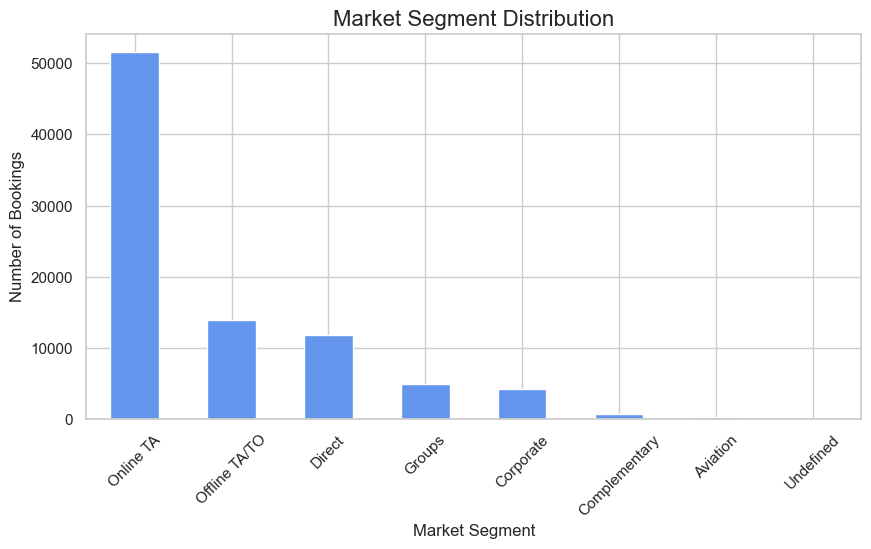

In [7]:
market = df["market_segment"].value_counts()

plt.figure(figsize=(10,5))

market.plot(
    kind="bar",
    color="cornflowerblue"
)

plt.title("Market Segment Distribution", fontsize=16)
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.savefig(
    "Visualizations/Figure5_MarketSegment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

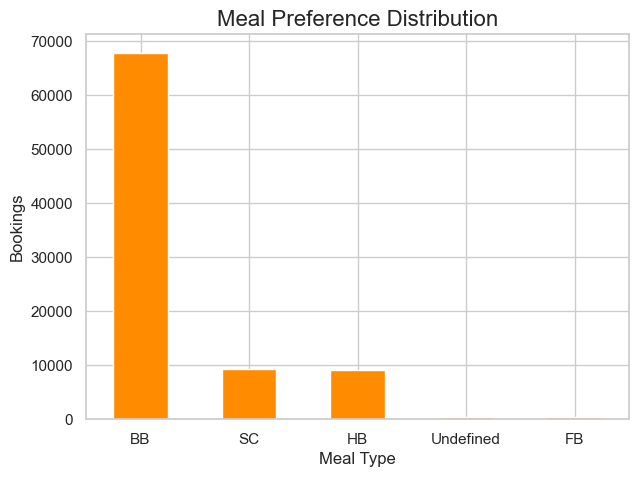

In [8]:
meal = df["meal"].value_counts()

plt.figure(figsize=(7,5))

meal.plot(
    kind="bar",
    color="darkorange"
)

plt.title("Meal Preference Distribution", fontsize=16)
plt.xlabel("Meal Type")
plt.ylabel("Bookings")
plt.xticks(rotation=0)

plt.savefig(
    "Visualizations/Figure6_MealPreference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

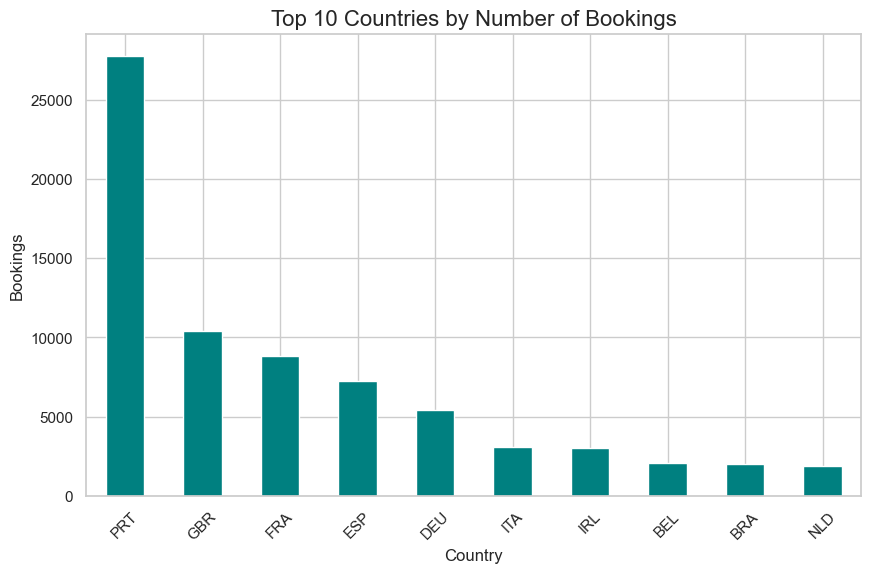

In [9]:
country = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

country.plot(
    kind="bar",
    color="teal"
)

plt.title("Top 10 Countries by Number of Bookings", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Bookings")
plt.xticks(rotation=45)

plt.savefig(
    "Visualizations/Figure7_TopCountries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

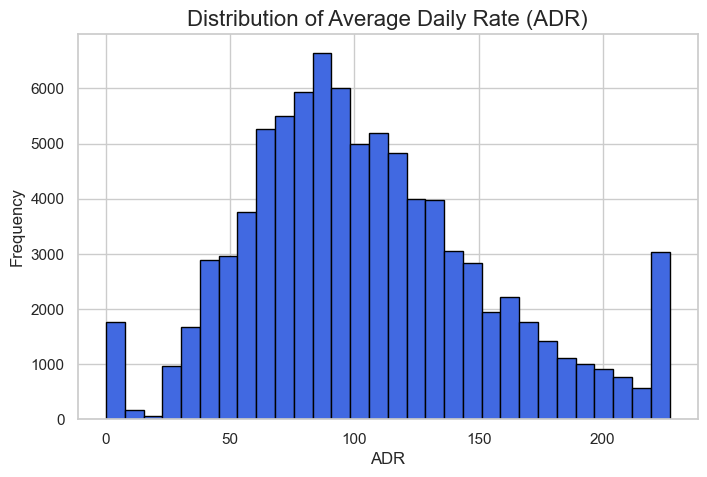

In [10]:
plt.figure(figsize=(8,5))

plt.hist(
    df["adr"],
    bins=30,
    color="royalblue",
    edgecolor="black"
)

plt.title("Distribution of Average Daily Rate (ADR)", fontsize=16)
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.savefig(
    "Visualizations/Figure8_ADRDistribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

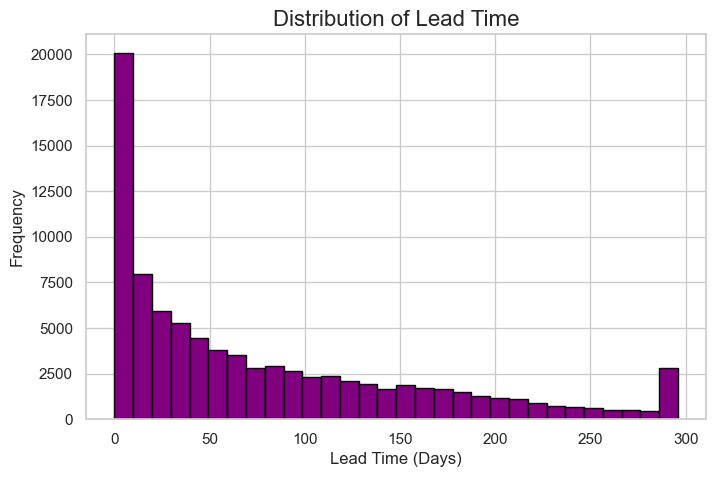

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    df["lead_time"],
    bins=30,
    color="purple",
    edgecolor="black"
)

plt.title("Distribution of Lead Time", fontsize=16)
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.savefig(
    "Visualizations/Figure9_LeadTime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

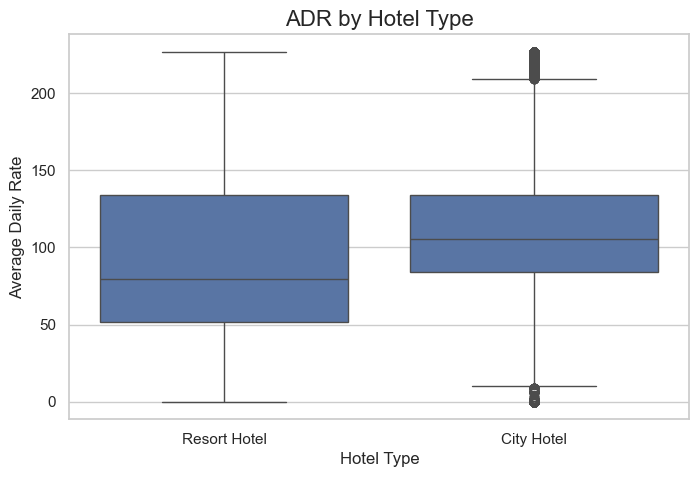

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="hotel",
    y="adr"
)

plt.title("ADR by Hotel Type", fontsize=16)
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate")

plt.savefig(
    "Visualizations/Figure10_ADR_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

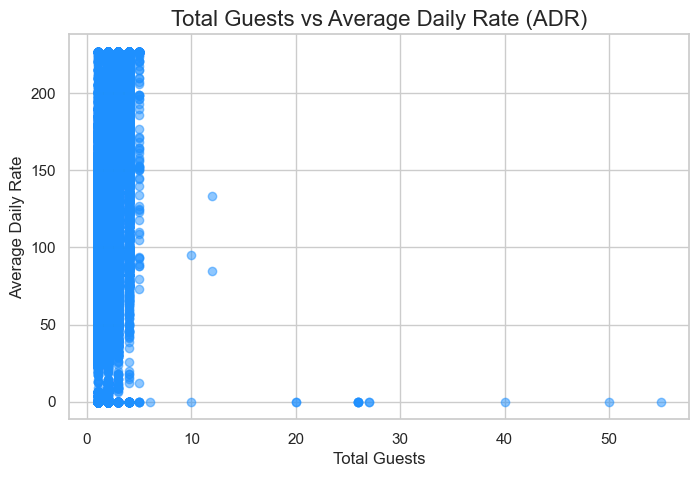

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["total_guests"],
    df["adr"],
    alpha=0.5,
    color="dodgerblue"
)

plt.title("Total Guests vs Average Daily Rate (ADR)", fontsize=16)
plt.xlabel("Total Guests")
plt.ylabel("Average Daily Rate")

plt.savefig(
    "Visualizations/Figure11_Guests_vs_ADR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

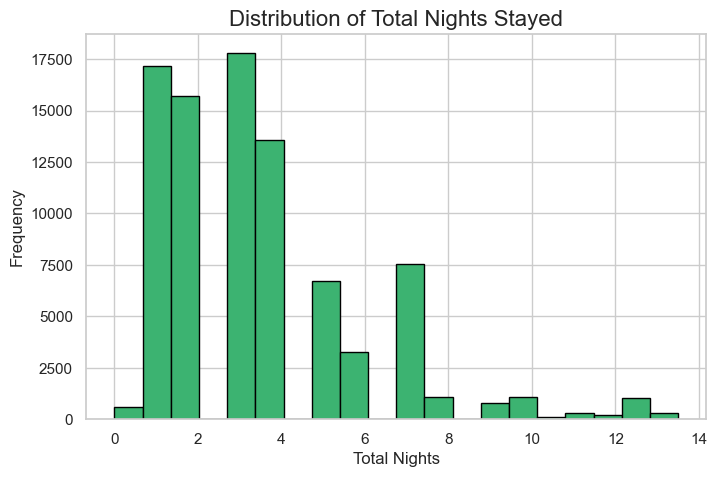

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    df["total_nights"],
    bins=20,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Distribution of Total Nights Stayed", fontsize=16)
plt.xlabel("Total Nights")
plt.ylabel("Frequency")

plt.savefig(
    "Visualizations/Figure12_TotalNights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

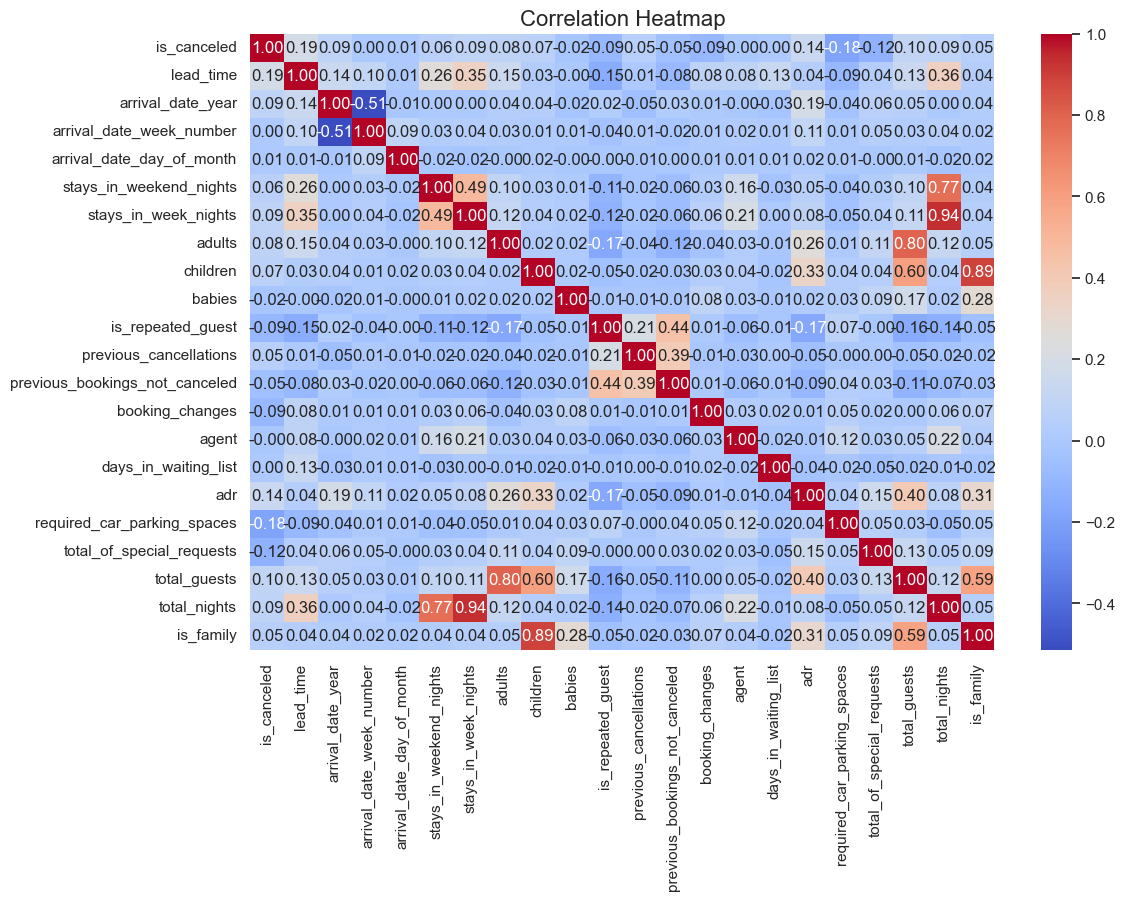

In [15]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.savefig(
    "Visualizations/Figure13_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "lead_time",
    "adr",
    "total_guests",
    "total_nights",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list"
]

X = df[features]
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

best_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10
)

best_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


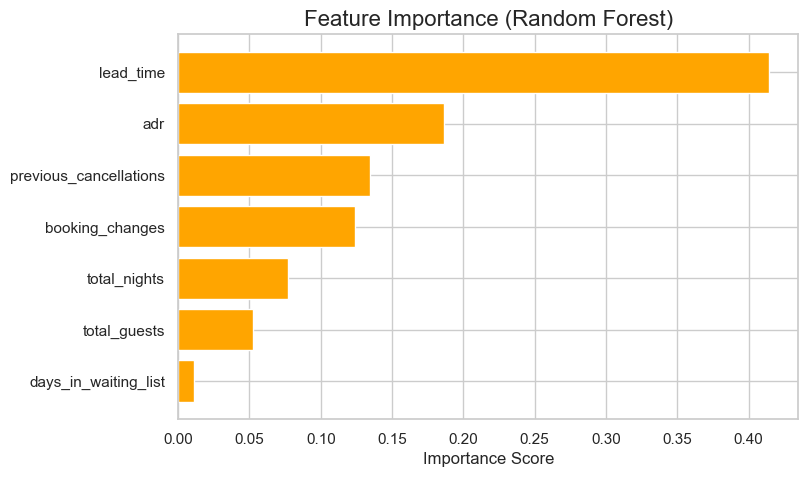

In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"],
    color="orange"
)

plt.gca().invert_yaxis()

plt.title("Feature Importance (Random Forest)", fontsize=16)
plt.xlabel("Importance Score")

plt.savefig(
    "Visualizations/Figure14_FeatureImportance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

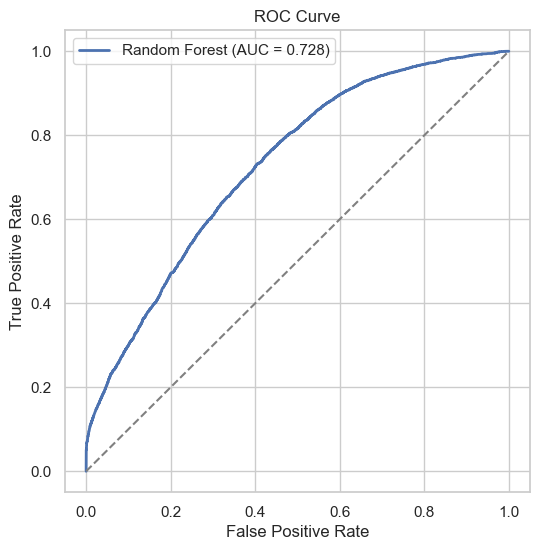

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})",
    linewidth=2
)

plt.plot([0,1],[0,1],'--', color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(
    "Visualizations/Figure15_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()